In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Read the data
df = pd.read_csv('/content/Bank Churn.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\
First few rows of the dataset:")
print(df.head())
print("\
Data Info:")
print(df.info())

Dataset Shape: (6956, 13)
First few rows of the dataset:
   CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure  \
0    15634602  Hargrave          619    France  Female   42       2   
1    15647311      Hill          608     Spain  Female   41       1   
2    15619304      Onio          502    France  Female   42       8   
3    15701354      Boni          699    France  Female   39       1   
4    15737888  Mitchell          850     Spain  Female   43       2   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              1          1               1        101348.88   
1   83807.86              1          0               1        112542.58   
2  159660.80              3          1               0        113931.57   
3       0.00              2          0               0         93826.63   
4  125510.82              1          1               1         79084.10   

   Exited  
0       1  
1       0  
2       1  
3       0  
4    

Evaluation Metrics:
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.825431   0.633028  0.253676  0.362205  0.608981
1        Random Forest  0.880747   0.831250  0.488971  0.615741  0.732432


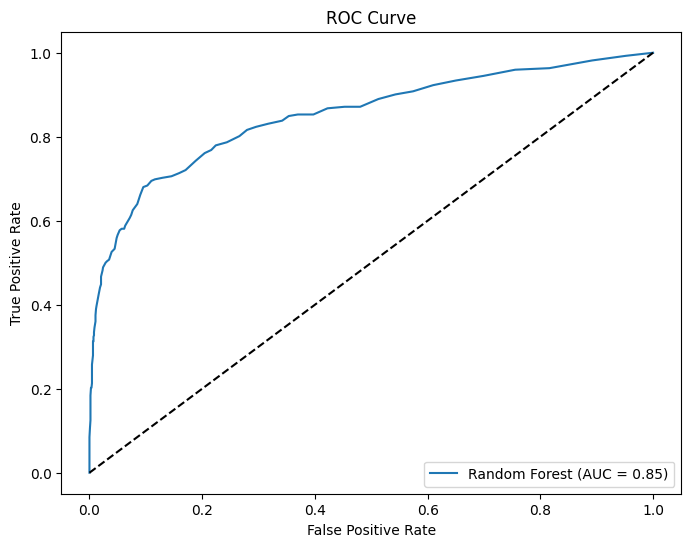

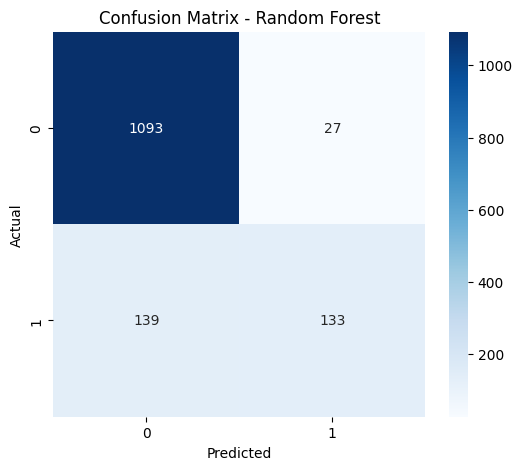

<ipython-input-2-a044c3a17560>:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


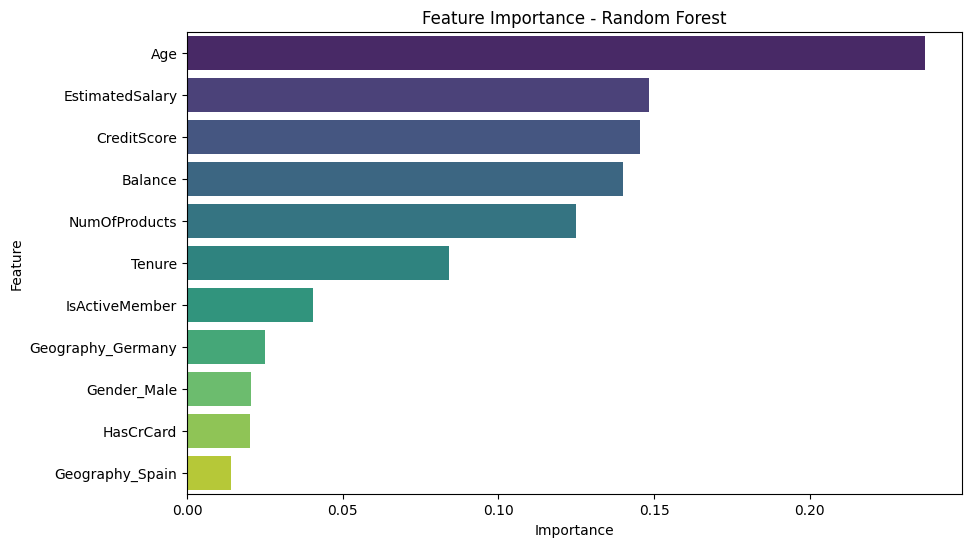

Evaluation Metrics Table:
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.825431   0.633028  0.253676  0.362205  0.608981
1        Random Forest  0.880747   0.831250  0.488971  0.615741  0.732432
Feature Importance Table:
              Feature  Importance
1                 Age    0.237036
7     EstimatedSalary    0.148387
0         CreditScore    0.145386
3             Balance    0.140107
4       NumOfProducts    0.125023
2              Tenure    0.084005
6      IsActiveMember    0.040462
8   Geography_Germany    0.024954
10        Gender_Male    0.020474
5           HasCrCard    0.020103
9     Geography_Spain    0.014061
Done


In [2]:
# Import necessary libraries for modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Data Preprocessing
# Drop columns that are likely non-informative: 'CustomerId' and 'Surname'
cols_to_drop = ['CustomerId', 'Surname']
df_model = df.drop(columns=cols_to_drop)

# Convert categorical variables: 'Geography' and 'Gender'
df_model = pd.get_dummies(df_model, drop_first=True)

# Define features and target
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling for numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# We'll try two models: Logistic Regression and Random Forest

# Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

# Evaluate Metrics function
def evaluate_model(y_true, y_pred, model_name='Model'):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred)
    return pd.DataFrame({
        'Model': [model_name],
        'Accuracy': [acc],
        'Precision': [prec],
        'Recall': [rec],
        'F1-Score': [f1],
        'ROC-AUC': [roc_auc]
    })

# Evaluate models
lr_results = evaluate_model(y_test, lr_pred, 'Logistic Regression')
rf_results = evaluate_model(y_test, rf_pred, 'Random Forest')

results_df = pd.concat([lr_results, rf_results], ignore_index=True)

print('Evaluation Metrics:')
print(results_df)

# Choose best model based on metrics (we'll pick RF if it has better metrics)
best_model = rf_model
best_model_name = 'Random Forest'

# ROC Curve and Confusion Matrix for best model

y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot the ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=best_model_name + ' (AUC = ' + str(round(roc_auc_score(y_test, y_prob),2)) + ')')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Plot Confusion Matrix for best model
cm = confusion_matrix(y_test, best_model.predict(X_test_scaled))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - ' + best_model_name)
plt.show()

# Feature Importance from Random Forest
importances = rf_model.feature_importances_
feature_names = X_train_scaled.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance - ' + best_model_name)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Print the tables for evaluation metrics and feature importance
print('Evaluation Metrics Table:')
print(results_df)

print('Feature Importance Table:')
print(feat_imp_df)

print('Done')

Decision Tree Accuracy: 0.8785919540229885


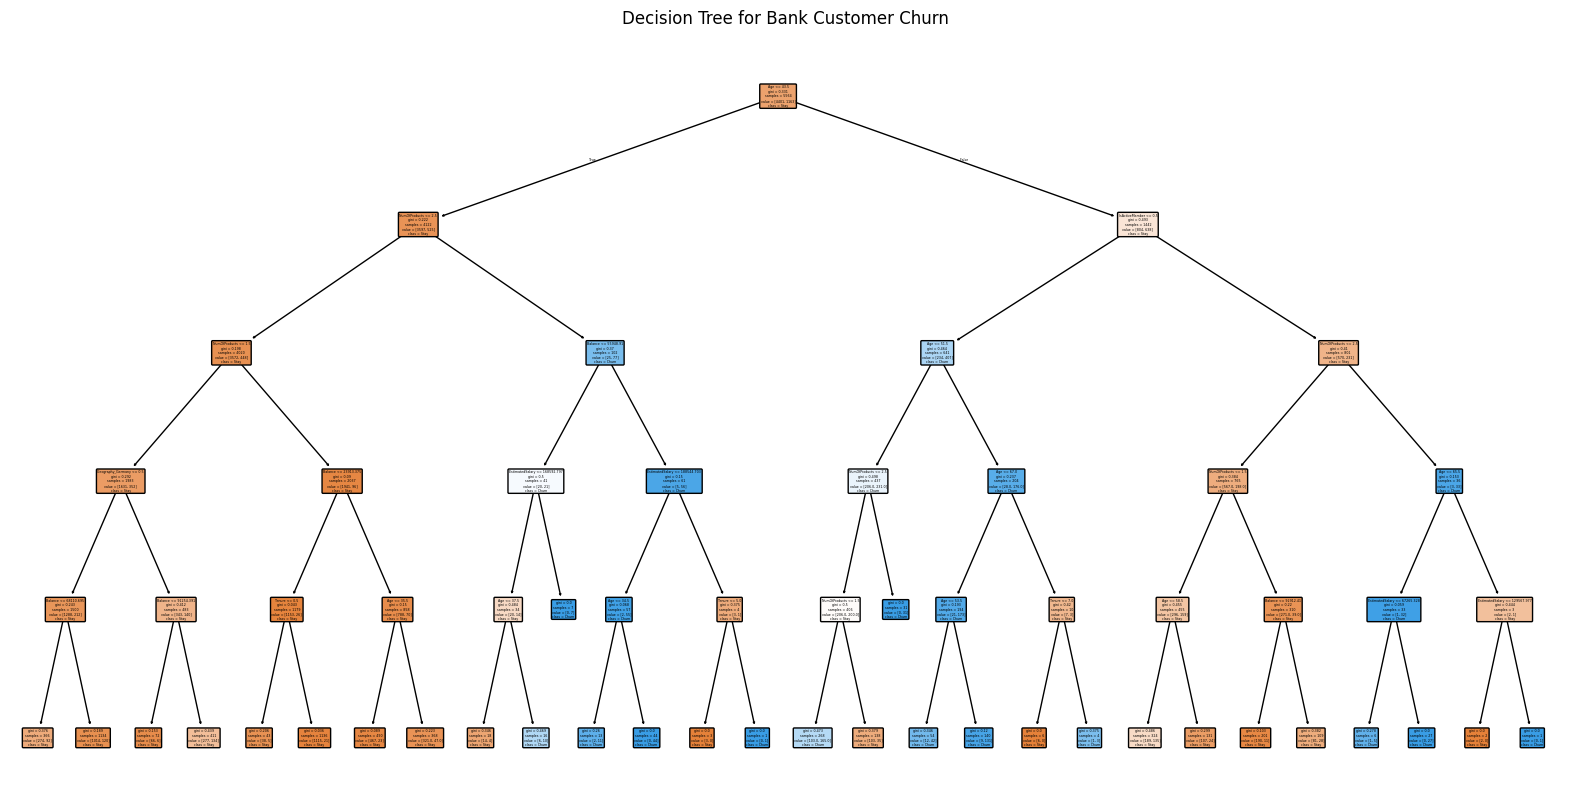

Decision tree generated and accuracy reported.


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
# Assuming the dataset is loaded in the same file that we have moved on
# Use the same dataframe name as before

df = pd.read_csv('Bank Churn.csv')

# Preprocessing: Drop rows with missing target values (if any)
df = df.dropna(subset=['Exited'])

df['Exited'] = df['Exited'].astype(int)

# Let us select relevant features. We'll follow previous model's features.
# We'll use: CreditScore, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, and dummy variables for Geography and Gender.

# Create dummy variables for categorical columns
categorical_cols = ['Geography', 'Gender']
df_dummies = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define features and target
feature_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
X = df_dummies[feature_cols]
y = df_dummies['Exited']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and fit the decision tree classifier
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print('Decision Tree Accuracy: ' + str(accuracy))

# Visualize the tree
plt.figure(figsize=(20,10))
plot_tree(dt_clf, feature_names=feature_cols, class_names=['Stay','Churn'], filled=True, rounded=True)
plt.title('Decision Tree for Bank Customer Churn')
plt.show()

print('Decision tree generated and accuracy reported.')